# Vocab map coordinate inspection

Loads the precomputed vocab-map coordinates for each built model
(`frontend/public/assets/<dir>/coords.u16.bin`) and plots them, so outlier
points that stretch the whole map's [0, 1] normalization can be spotted and
a better per-model clip range chosen by hand.

Read-only — this notebook doesn't write anything back to `frontend/` or
`backend/`. It's just for looking at the values and deciding on numbers.

In [1]:
%matplotlib inline
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ASSETS_DIR = Path("../frontend/public/assets").resolve()
assert ASSETS_DIR.exists(), f"assets dir not found: {ASSETS_DIR}"
ASSETS_DIR

Matplotlib is building the font cache; this may take a moment.


PosixPath('/Users/akochoska@ideo.com/Documents/local/pollen/frontend/public/assets')

## Models with built assets

In [2]:
models = json.loads((ASSETS_DIR / "models.json").read_text())["models"]
for m in models:
    print(f"{m['model_name']:50s} -> {m['dir']:45s} ({m['vocab_size']:,} tokens)")

mlx-community/Qwen3-4B-4bit                        -> mlx-community__Qwen3-4B-4bit                  (151,936 tokens)
mlx-community/Llama-3.2-3B-Instruct-4bit           -> mlx-community__Llama-3.2-3B-Instruct-4bit     (128,256 tokens)
mlx-community/Mistral-7B-Instruct-v0.3-4bit        -> mlx-community__Mistral-7B-Instruct-v0.3-4bit  (32,768 tokens)


In [3]:
def load_coords(model_dir: str) -> np.ndarray:
    """(N, 2) float array of x, y in [0, 1] — decoded exactly the way the
    frontend does in lib/loadVocabMap.ts (uint16 le / 65535)."""
    manifest = json.loads((ASSETS_DIR / model_dir / "manifest.json").read_text())
    raw = np.fromfile(ASSETS_DIR / model_dir / "coords.u16.bin", dtype="<u2")
    assert raw.size == manifest["vocab_size"] * 2, "coords length != vocab_size*2"
    return raw.reshape(-1, 2).astype(np.float64) / 65535.0


coords_by_model = {m["dir"]: load_coords(m["dir"]) for m in models}
{d: xy.shape for d, xy in coords_by_model.items()}

{'mlx-community__Qwen3-4B-4bit': (151936, 2),
 'mlx-community__Llama-3.2-3B-Instruct-4bit': (128256, 2),
 'mlx-community__Mistral-7B-Instruct-v0.3-4bit': (32768, 2)}

## Percentile summary

The tell for "a few weird points are stretching the whole map": a big gap
between `p0`/`p100` (the true min/max) and `p1`/`p99`. If the middle 98% of
points sit in a narrow band but the absolute extremes are way outside it,
those extremes are single points (or a handful) dragging the [0, 1]
normalization — everything else gets compressed into a fraction of the
visible map.

In [4]:
def summarize(xy: np.ndarray) -> dict:
    pct = [0, 0.5, 1, 5, 25, 50, 75, 95, 99, 99.5, 100]
    return {
        axis: {f"p{p}": round(float(np.percentile(xy[:, i], p)), 4) for p in pct}
        for i, axis in enumerate(["x", "y"])
    }


for m in models:
    s = summarize(coords_by_model[m["dir"]])
    print(f"\n=== {m['model_name']} ({m['dir']}) — n={len(coords_by_model[m['dir']]):,} ===")
    for axis in ("x", "y"):
        row = s[axis]
        print(f"  {axis}: p0={row['p0']:.4f}  p1={row['p1']:.4f}  p50={row['p50']:.4f}  "
              f"p99={row['p99']:.4f}  p100={row['p100']:.4f}")


=== mlx-community/Qwen3-4B-4bit (mlx-community__Qwen3-4B-4bit) — n=151,936 ===
  x: p0=0.0000  p1=0.3881  p50=0.5341  p99=0.7058  p100=1.0000
  y: p0=0.0000  p1=0.3187  p50=0.5094  p99=0.6578  p100=1.0000

=== mlx-community/Llama-3.2-3B-Instruct-4bit (mlx-community__Llama-3.2-3B-Instruct-4bit) — n=128,256 ===
  x: p0=0.0000  p1=0.4747  p50=0.6929  p99=0.9103  p100=1.0000
  y: p0=0.0000  p1=0.1909  p50=0.5249  p99=0.9615  p100=1.0000

=== mlx-community/Mistral-7B-Instruct-v0.3-4bit (mlx-community__Mistral-7B-Instruct-v0.3-4bit) — n=32,768 ===
  x: p0=0.0000  p1=0.1332  p50=0.6331  p99=0.9153  p100=1.0000
  y: p0=0.0000  p1=0.0522  p50=0.4015  p99=0.7915  p100=1.0000


## Full-range scatter — what the app actually renders today

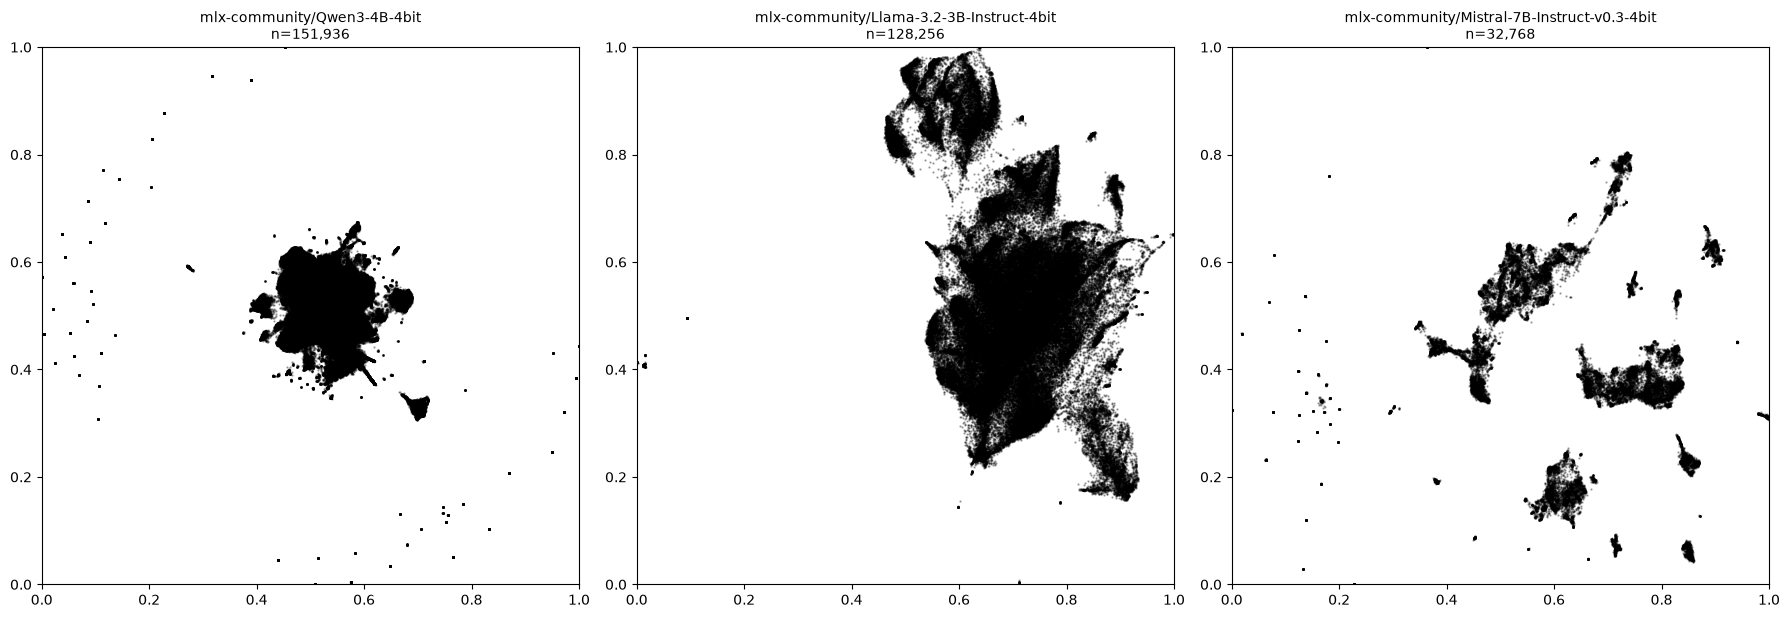

In [5]:
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 6))
if len(models) == 1:
    axes = [axes]
for ax, m in zip(axes, models):
    xy = coords_by_model[m["dir"]]
    ax.scatter(xy[:, 0], xy[:, 1], s=0.5, alpha=0.3, color="black")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_title(f"{m['model_name']}\nn={len(xy):,}", fontsize=10)
plt.tight_layout()
plt.show()

## Marginal distributions (log scale)

Log-scaled y-axis so a handful of outlier points still show up as visible
bars even though the main mass dwarfs them on a linear count.

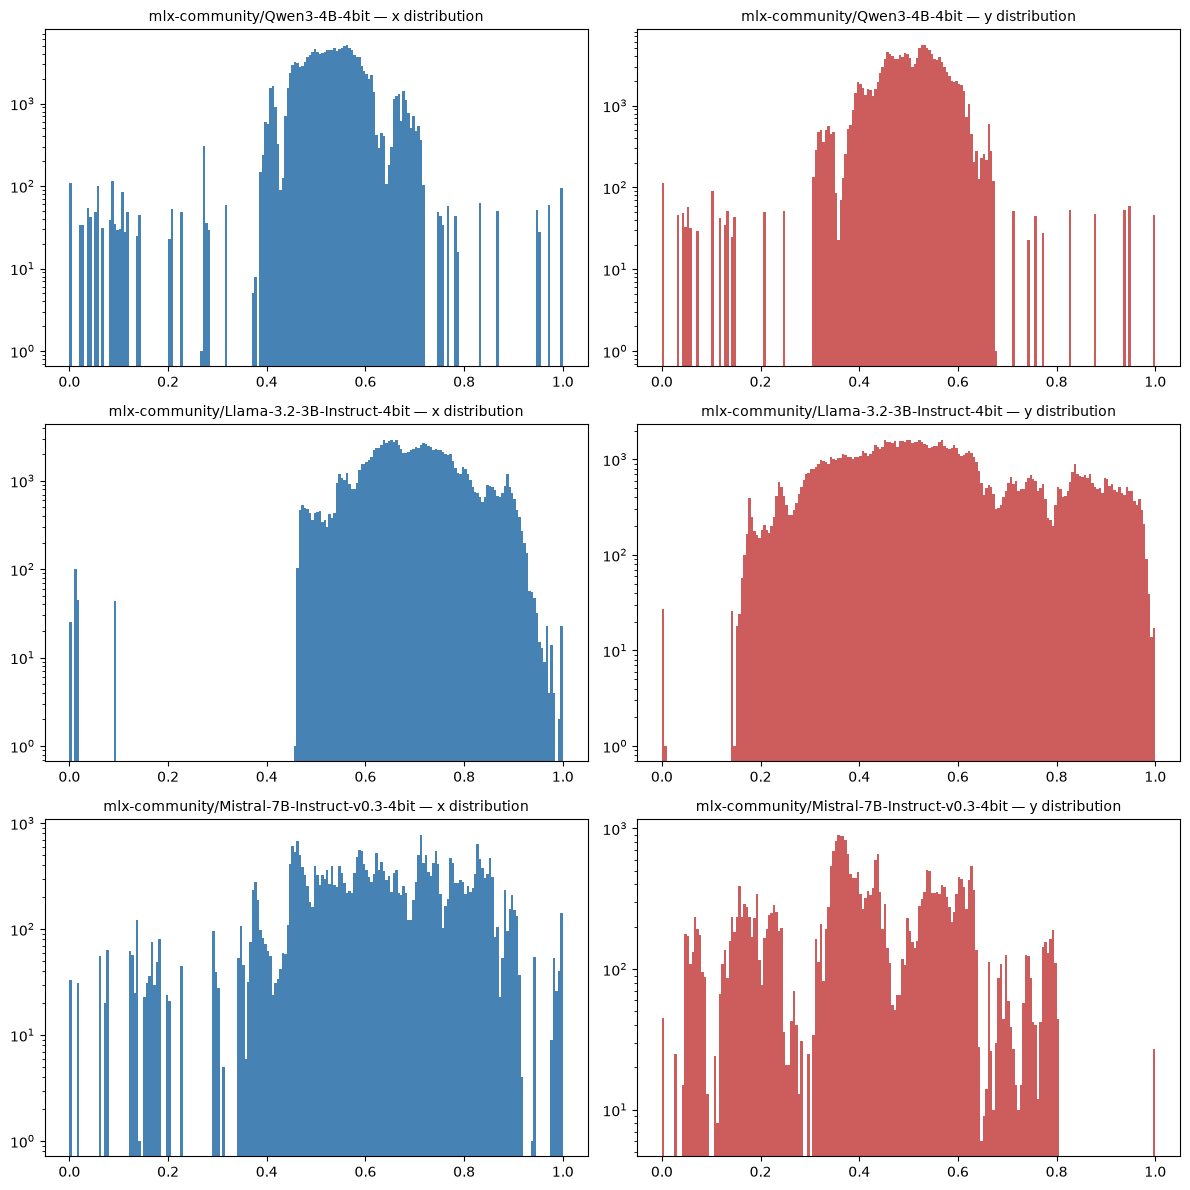

In [6]:
fig, axes = plt.subplots(len(models), 2, figsize=(12, 4 * len(models)))
if len(models) == 1:
    axes = [axes]
for row, m in zip(axes, models):
    xy = coords_by_model[m["dir"]]
    row[0].hist(xy[:, 0], bins=200, color="steelblue")
    row[0].set_yscale("log")
    row[0].set_title(f"{m['model_name']} — x distribution", fontsize=10)
    row[1].hist(xy[:, 1], bins=200, color="indianred")
    row[1].set_yscale("log")
    row[1].set_title(f"{m['model_name']} — y distribution", fontsize=10)
plt.tight_layout()
plt.show()

## Try candidate limits

Edit `CANDIDATE_LIMITS` below with a `(low, high)` pair per axis per model
(start from the percentiles above — e.g. `p1`/`p99`), then re-run this cell.
Left plot: full range with your cut lines in red. Right plot: only the
points inside your box, rescaled to fill the frame — this is what the map
would look like if it were re-normalized to that range instead of [0, 1].
`% kept` tells you how much of the vocabulary you'd be clipping away, so you
don't cut so tight you start losing real tokens, not just outliers.

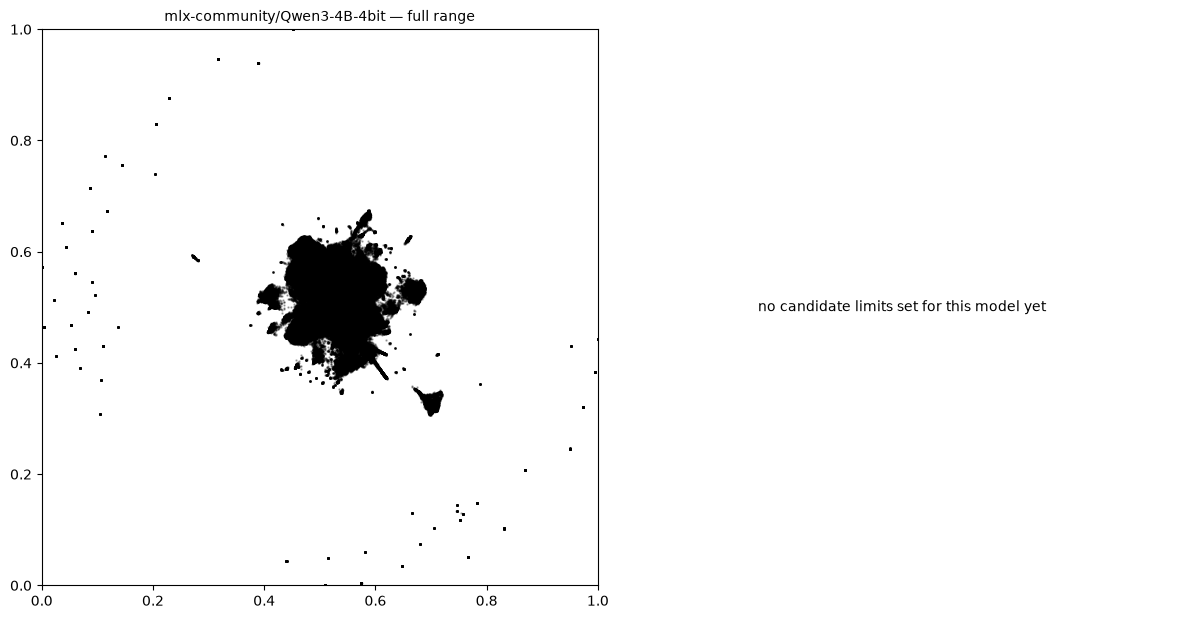

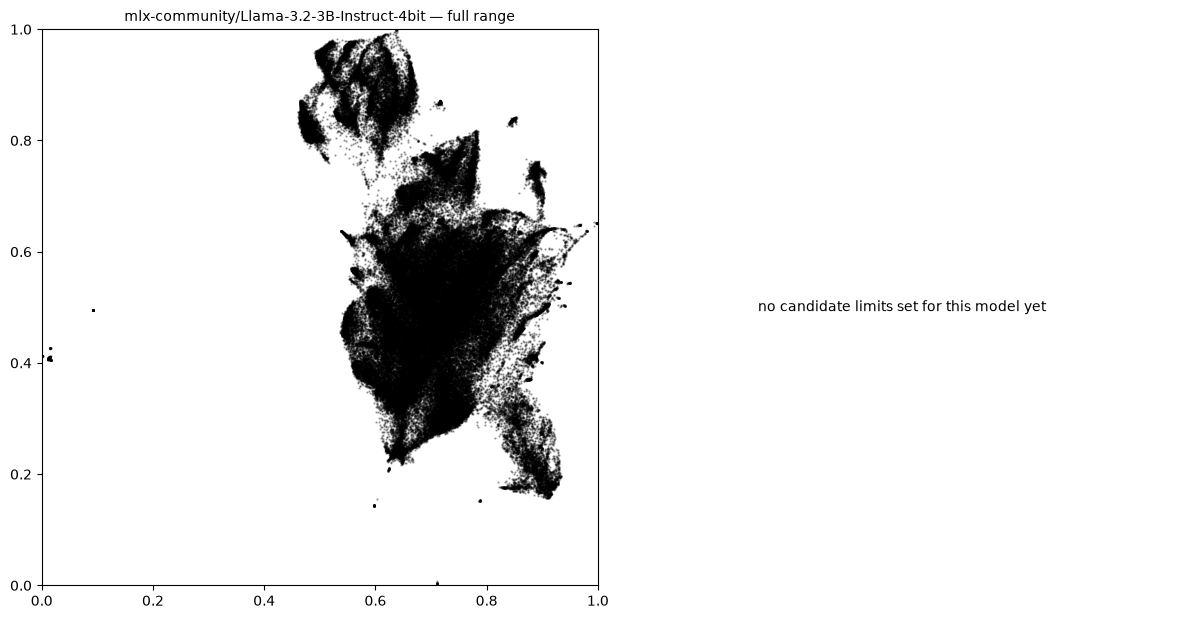

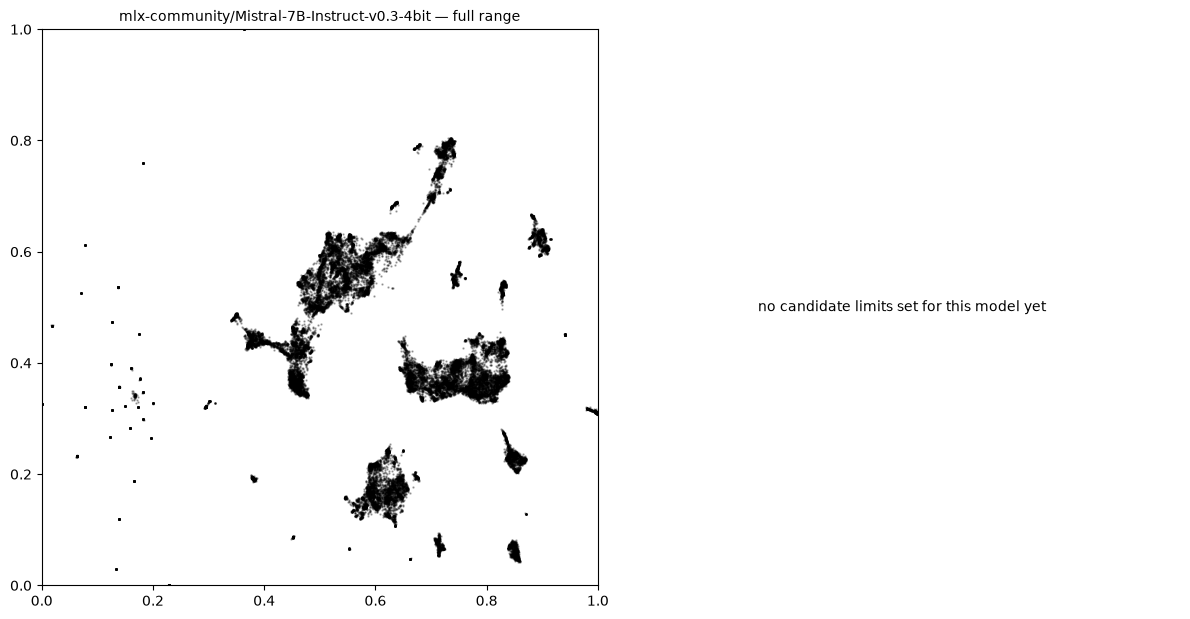

In [7]:
# Fill in per model dir after reading the plots/percentiles above.
CANDIDATE_LIMITS = {
    # "mlx-community__Qwen3-4B-4bit": {"x": (0.05, 0.95), "y": (0.05, 0.95)},
}

for m in models:
    d = m["dir"]
    xy = coords_by_model[d]
    lims = CANDIDATE_LIMITS.get(d)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].scatter(xy[:, 0], xy[:, 1], s=0.5, alpha=0.3, color="black")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_aspect("equal")
    axes[0].set_title(f"{m['model_name']} — full range", fontsize=10)

    if lims:
        x_lo, x_hi = lims["x"]
        y_lo, y_hi = lims["y"]
        axes[0].axvline(x_lo, color="red", lw=1)
        axes[0].axvline(x_hi, color="red", lw=1)
        axes[0].axhline(y_lo, color="red", lw=1)
        axes[0].axhline(y_hi, color="red", lw=1)

        mask = (xy[:, 0] >= x_lo) & (xy[:, 0] <= x_hi) & (xy[:, 1] >= y_lo) & (xy[:, 1] <= y_hi)
        clipped = xy[mask]
        pct_kept = 100 * len(clipped) / len(xy)

        axes[1].scatter(clipped[:, 0], clipped[:, 1], s=0.5, alpha=0.3, color="black")
        axes[1].set_xlim(x_lo, x_hi)
        axes[1].set_ylim(y_lo, y_hi)
        axes[1].set_aspect("equal")
        axes[1].set_title(f"clipped preview — {pct_kept:.2f}% of points kept", fontsize=10)
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "no candidate limits set for this model yet", ha="center", va="center")

    plt.tight_layout()
    plt.show()

## Next step

Once `CANDIDATE_LIMITS` looks right for every model (main cluster fills the
frame, `% kept` isn't discarding a meaningful chunk of real vocabulary),
report the chosen `(x_lo, x_hi)` / `(y_lo, y_hi)` per model dir back —
wiring them in (either as a re-bake in `build_assets.py`'s normalization
step, or as a per-model clip applied at render time) is a separate,
follow-up change, not done by this notebook.